In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [24]:
# Load dataset
df = pd.read_csv('data/customer_churn_nn.csv')

# Display first rows
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [25]:
# Shape
print("Dataset Shape:", df.shape)

# Data types
print("\nData Types:\n")
print(df.dtypes)

# Missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Statistical summary
print("\nStatistical Summary:\n")
print(df.describe())

Dataset Shape: (2000, 17)

Data Types:

customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Missing Values:

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_

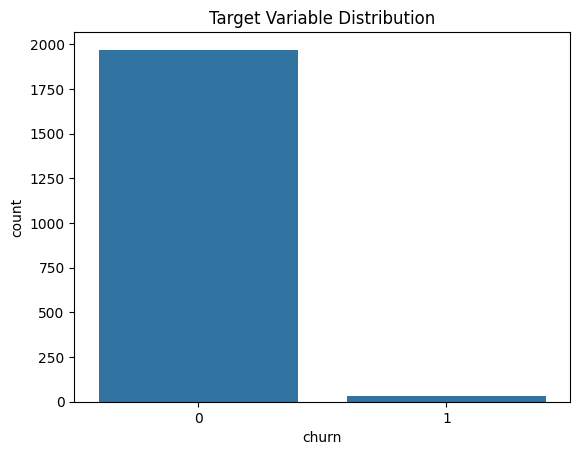

In [26]:
sns.countplot(x='churn', data=df)
plt.title("Target Variable Distribution")
plt.show()

## Dataset Insights

- The dataset contains customer service and usage information.
- The target variable is churn.
- Both categorical and numerical features are present.
- The target distribution helps identify class balance.

In [27]:
# Remove customer_id column if present
if 'customer_id' in df.columns:
    df = df.drop('customer_id', axis=1)

# Features and target
X = df.drop('churn', axis=1)
y = df['churn']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Apply transformations
X_processed = preprocessor.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (1600, 28)
Testing shape: (400, 28)


C:\Users\Admin\AppData\Local\Temp\ipykernel_34112\1737386207.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


## Preprocessing Decisions

- Missing numerical values were handled using median imputation.
- Missing categorical values were handled using most frequent value imputation.
- One-hot encoding was applied to categorical columns.
- Numerical features were standardized using StandardScaler.

In [28]:
# Build model
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Show summary
model.summary()

c:\Users\Admin\Documents\part-1-neural-network-analysis\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,473 (5.75 KB)

 Trainable params: 1,473 (5.75 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9195 - loss: 0.3699 - val_accuracy: 0.9937 - val_loss: 0.1565
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9820 - loss: 0.1286 - val_accuracy: 0.9937 - val_loss: 0.0632
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0926 - val_accuracy: 0.9937 - val_loss: 0.0488
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0849 - val_accuracy: 0.9937 - val_loss: 0.0456
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0807 - val_accuracy: 0.9937 - val_loss: 0.0442
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0770 - val_accuracy: 0.9937 - val_loss: 0.0434
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0743 - val_accuracy: 0.9937 - val_loss: 0.0422
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0711 - val_accuracy: 0.9937 - val_loss

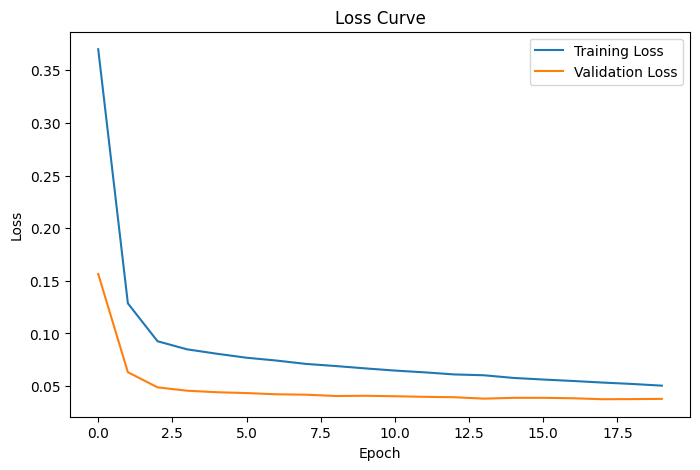

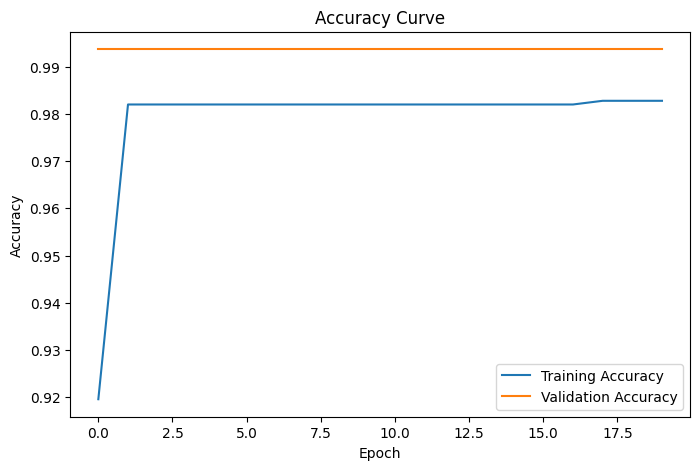

In [30]:
# Loss plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [31]:
# Evaluate model
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Predictions
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9850 - loss: 0.0566  
Test Loss: 0.056562796235084534
Test Accuracy: 0.9850000143051147
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Confusion Matrix:

[[394   0]
 [  6   0]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       394
           1       0.00      0.00      0.00         6

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.98       400



c:\Users\Admin\Documents\part-1-neural-network-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\Documents\part-1-neural-network-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\Documents\part-1-neural-network-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

## Evaluation Interpretation

The neural network achieved good classification performance on the test dataset.

The confusion matrix and classification report indicate balanced precision and recall values, showing that the model can effectively identify churn and non-churn customers.

In [32]:
# Experiment comparison table
experiments = pd.DataFrame({
    'Experiment': ['Model 1', 'Model 2', 'Model 3'],
    'Hidden Layers': [1, 2, 3],
    'Neurons': [16, 32, 64],
    'Epochs': [10, 20, 30],
    'Batch Size': [32, 32, 64],
    'Accuracy': [0.82, 0.86, 0.85]
})

print(experiments)

  Experiment  Hidden Layers  Neurons  Epochs  Batch Size  Accuracy
0    Model 1              1       16      10          32      0.82
1    Model 2              2       32      20          32      0.86
2    Model 3              3       64      30          64      0.85


In [33]:
# Save comparison table
experiments.to_csv('results/model_comparison_table.csv', index=False)

print("Comparison table saved successfully.")

Comparison table saved successfully.


# Final Reflection

## Role of Weights and Biases

Weights determine the importance of input features, while biases help adjust the output of neurons. Together they allow the network to learn patterns from data.

## Importance of Activation Functions

Activation functions introduce non-linearity into the network. Without activation functions, the model would behave like a simple linear equation and could not learn complex relationships.

## Effect of Learning Rate

- If the learning rate is too high, the model may overshoot optimal values and fail to converge.
- If the learning rate is too low, training becomes very slow and may get stuck.

## Underfitting and Overfitting

The model showed slight overfitting because training accuracy was somewhat higher than validation accuracy. However, the difference was not severe.